# Pavement temperatures under climate change
Plots climate rasters for Serbia with an OSM basemap and country outline.  
Calculates future pavement temperatures experienced by the national road network considering urban heat islands and future increases of 2 °C in the medium future

In [37]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm
from rasterio.warp import reproject, Resampling
import rasterio
import geopandas as gpd
from pathlib import Path
import contextily as cx
from scipy.ndimage import zoom

## ⚙️ Configuration
Edit the variables in the cell below before running.

In [38]:
BASE_DIR = Path.cwd().parent
data_path = BASE_DIR / "input_files"
intermediate_results_path = BASE_DIR / "intermediate_results"

# ── Single-folder mode ────────────────────────────────────────────────────────
GEOTIF_FOLDER = "."          # Folder containing your .tif / .tiff files

# ── Difference mode ───────────────────────────────────────────────────────────
# Set BOTH paths to activate difference mode; leave as None for folder mode.
HISTORIC_TIF = data_path / "Temperatures climate change" / "TX7D_1961-1990.tif"          
CURRENT_TIF  = data_path / "Temperatures climate change" / "TX7D_1991-2020.tif" 
CURRENT_PAV_TEMP_TIF  = data_path / "Temperatures climate change" / "TPAV_2021-2025.tif"   
DEGREE_OF_URBANIZATION_TIF = data_path / "GHS_SMOD_E2025_GLOBE_R2023A_54009_1000_V2_0_R4_C20.tif"       

# ── Shared settings ───────────────────────────────────────────────────────────
OUTPUT_FOLDER  = BASE_DIR/ "figures" / "temperature"     # Folder to save PNGs; set to None to only display
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
COLORMAP       = "RdYlBu_r"  # Colormap for individual / source panels
DIFF_COLORMAP  = "RdBu_r"    # Diverging colormap for the difference panel
DPI            = 300


# ── Bins & colours: absolute temperature panels (°C) ─────────────────────────
# Covers 24–35 °C range, finer steps in the middle where most data falls
ABS_BINS   = [24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
ABS_COLORS = [
    "#2166ac",  # 24–26  cool blue
    "#4393c3",  # 26–27
    "#92c5de",  # 27–28
    "#d1e5f0",  # 28–29  light blue
    "#fddbc7",  # 29–30  light orange
    "#f4a582",  # 30–31
    "#d6604d",  # 31–32
    "#b2182b",  # 32–33
    "#800026",  # 33–34
    "#4d0010",  # 34–35  deep red
]

# ── Bins & colours: difference panel (°C, current − historic) ─────────────────
# Asymmetric: finer resolution on the positive (warming) side
DIFF_BINS   = [-2.5, -1.5, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5]
DIFF_COLORS = [
    "#2166ac",  # −2.5 – −1.5  strong cooling
    "#92c5de",  # −1.5 – −0.5  slight cooling
    "#d1e5f0",  # −0.5 –  0.0  near zero / slight cooling
    "#fddbc7",  #  0.0 –  0.5  near zero / slight warming
    "#f4a582",  #  0.5 –  1.0
    "#d6604d",  #  1.0 –  1.5
    "#b2182b",  #  1.5 –  2.0
    "#67000d",  #  2.0 –  2.5  extreme warming
]

## 🔧 Helper functions

In [39]:
def load_serbia_outline():
    """Return a GeoDataFrame with Serbia polygon in EPSG:4326."""
    countries = gpd.read_file(
        "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
    )
    serbia = countries[countries["NAME"].str.lower() == "serbia"]
    if serbia.empty:
        raise ValueError("Serbia not found in Natural Earth dataset.")
    return serbia.to_crs("EPSG:4326")


def read_tif(path):
    """Open a GeoTIFF; return (data_2d, bounds, crs) with nodata → NaN."""
    with rasterio.open(path) as src:
        data   = src.read(1).astype(float)
        nodata = src.nodata
        bounds = src.bounds
        crs    = src.crs
    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)
    return data, bounds, crs


def resample_to_match(data_src, data_ref):
    """Bilinear-resample data_src to the same shape as data_ref."""
    zoom_r = data_ref.shape[0] / data_src.shape[0]
    zoom_c = data_ref.shape[1] / data_src.shape[1]
    nan_mask       = np.isnan(data_src).astype(float)
    resampled      = zoom(np.nan_to_num(data_src, nan=0.0), (zoom_r, zoom_c), order=1)
    resampled_mask = zoom(nan_mask, (zoom_r, zoom_c), order=1) > 0.5
    resampled[resampled_mask] = np.nan
    return resampled


def _reproject_bounds_to_3857(bounds, crs):
    """Convert raster bounds from native CRS to Web Mercator (EPSG:3857)."""
    import pyproj
    transformer = pyproj.Transformer.from_crs(crs, "EPSG:3857", always_xy=True)
    left,  bottom = transformer.transform(bounds.left,  bounds.bottom)
    right, top    = transformer.transform(bounds.right, bounds.top)
    return left, bottom, right, top


def _apply_panel_style(ax, title, serbia_3857):
    """White-background panel with Serbia outline and OSM basemap."""
    serbia_3857.plot(ax=ax, facecolor="none", edgecolor="#333333",
                     linewidth=1.5, zorder=4)
    cx.add_basemap(ax=ax, source=cx.providers.OpenStreetMap.Mapnik,
                   alpha=0.35, attribution=False, zoom="auto")
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10, color="#222222")


def _add_colorbar(fig, ax, img, label=None):
    cbar = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.03, shrink=0.85)
    cbar.ax.tick_params(labelsize=8)
    if label:
        cbar.set_label(label, fontsize=8)


def _save_or_show(fig, output_folder, stem):
    if output_folder:
        os.makedirs(output_folder, exist_ok=True)
        out_path = os.path.join(output_folder, f"{stem}.png")
        fig.savefig(out_path, dpi=DPI, bbox_inches="tight")
        print(f"  Saved → {out_path}")
    plt.show()

def mask_to_serbia(data, bounds, crs, serbia_gdf):
    """
    Return a copy of `data` with all pixels outside Serbia set to NaN.
    Uses rasterio.features.geometry_mask to burn the Serbia polygon onto
    the raster grid, then masks out-of-bounds cells.
    """
    from rasterio.transform import from_bounds
    from rasterio.features import geometry_mask
    from shapely.geometry import mapping

    serbia_proj = serbia_gdf.to_crs(crs)
    rows, cols  = data.shape
    transform   = from_bounds(
        bounds.left, bounds.bottom, bounds.right, bounds.top, cols, rows
    )
    outside = geometry_mask(
        [mapping(geom) for geom in serbia_proj.geometry],
        out_shape=(rows, cols),
        transform=transform,
        invert=False,
    )
    masked = data.copy()
    masked[outside] = np.nan
    return masked


print("Helper functions defined ✓")

Helper functions defined ✓


## 📥 Load Serbia outline

In [40]:
print("Loading Serbia outline …")
# Load country outline
world_path = data_path / "ne_10m_admin_0_countries.shp"
world = gpd.read_file(world_path)
country_bounds = world.loc[world.SOV_A3 == 'SRB'].bounds
country_plot = world.loc[world.SOV_A3 == 'SRB']
serbia_3857 = country_plot.to_crs(3857)
print(f"Loaded Serbia: {len(serbia_3857)} polygon(s)")

Loading Serbia outline …
Loaded Serbia: 1 polygon(s)


## 🗺️ Single-folder mode
Plots every GeoTIFF in `GEOTIF_FOLDER` as an individual map.

In [41]:
def plot_geotiff(tif_path, serbia_3857, output_folder):
    stem = os.path.splitext(os.path.basename(tif_path))[0]
    data, bounds, crs = read_tif(tif_path)

    # Raster bounds → Web Mercator for contextily
    l, b, r, t = _reproject_bounds_to_3857(bounds, crs)

    vmin, vmax = np.nanpercentile(data, [2, 98])

    # Build a transparent RGBA image from the colormap
    norm      = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap_obj  = plt.get_cmap(COLORMAP)
    color_arr = cmap_obj(norm(data))
    color_arr[np.isnan(data)] = [0, 0, 0, 0]   # transparent nodata

    fig, ax = plt.subplots(figsize=(10, 8), facecolor="white")

    # Raster
    img = ax.imshow(
        data,
        extent=[l, r, b, t],
        origin="upper",
        cmap=COLORMAP,
        vmin=vmin, vmax=vmax,
        interpolation="bilinear",
        alpha=0.75,
        zorder=3,
    )

    _apply_panel_style(ax, stem, serbia_3857)

    # Colorbar via a ScalarMappable so it survives axis("off")
    sm = plt.cm.ScalarMappable(cmap=COLORMAP, norm=norm)
    sm.set_array([])
    _add_colorbar(fig, ax, sm)

    plt.tight_layout()
    _save_or_show(fig, output_folder, stem)


# ── Run ───────────────────────────────────────────────────────────────────────
patterns  = ["*.tif", "*.tiff", "*.TIF", "*.TIFF"]
tif_files = []
for pat in patterns:
    tif_files.extend(glob.glob(os.path.join(GEOTIF_FOLDER, pat)))

if not tif_files:
    print(f"⚠ No GeoTIFF files found in '{GEOTIF_FOLDER}'")
else:
    print(f"Found {len(tif_files)} GeoTIFF(s)\n")
    for tif_path in sorted(tif_files):
        print(f"Plotting: {os.path.basename(tif_path)}")
        try:
            plot_geotiff(tif_path, serbia_3857, OUTPUT_FOLDER)
        except Exception as exc:
            print(f"  ⚠ Skipped ({exc})")

⚠ No GeoTIFF files found in '.'


## 📊 Difference mode
Three-panel comparison: **Historic | Current | Difference** (current − historic).  
Set `HISTORIC_TIF` and `CURRENT_TIF` at the top before running this cell.

Difference mode
  Historic : c:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\input_files\Temperatures climate change\TX7D_1961-1990.tif
  Current  : c:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\input_files\Temperatures climate change\TX7D_1991-2020.tif

─────────────────────────────────────────────
  Difference statistics (within Serbia)
  Pixels used         : 880
  Min  Δ              : 0.9425 °C
  Max  Δ              : 2.4907 °C
  Mean Δ              : 1.8558 °C
  Median Δ            : 1.8692 °C
  Std dev Δ           : 0.2516 °C
─────────────────────────────────────────────
  Saved → c:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\figures\temperature\diff_TX7D_1961-1990_vs_TX7D_1991-2020.png


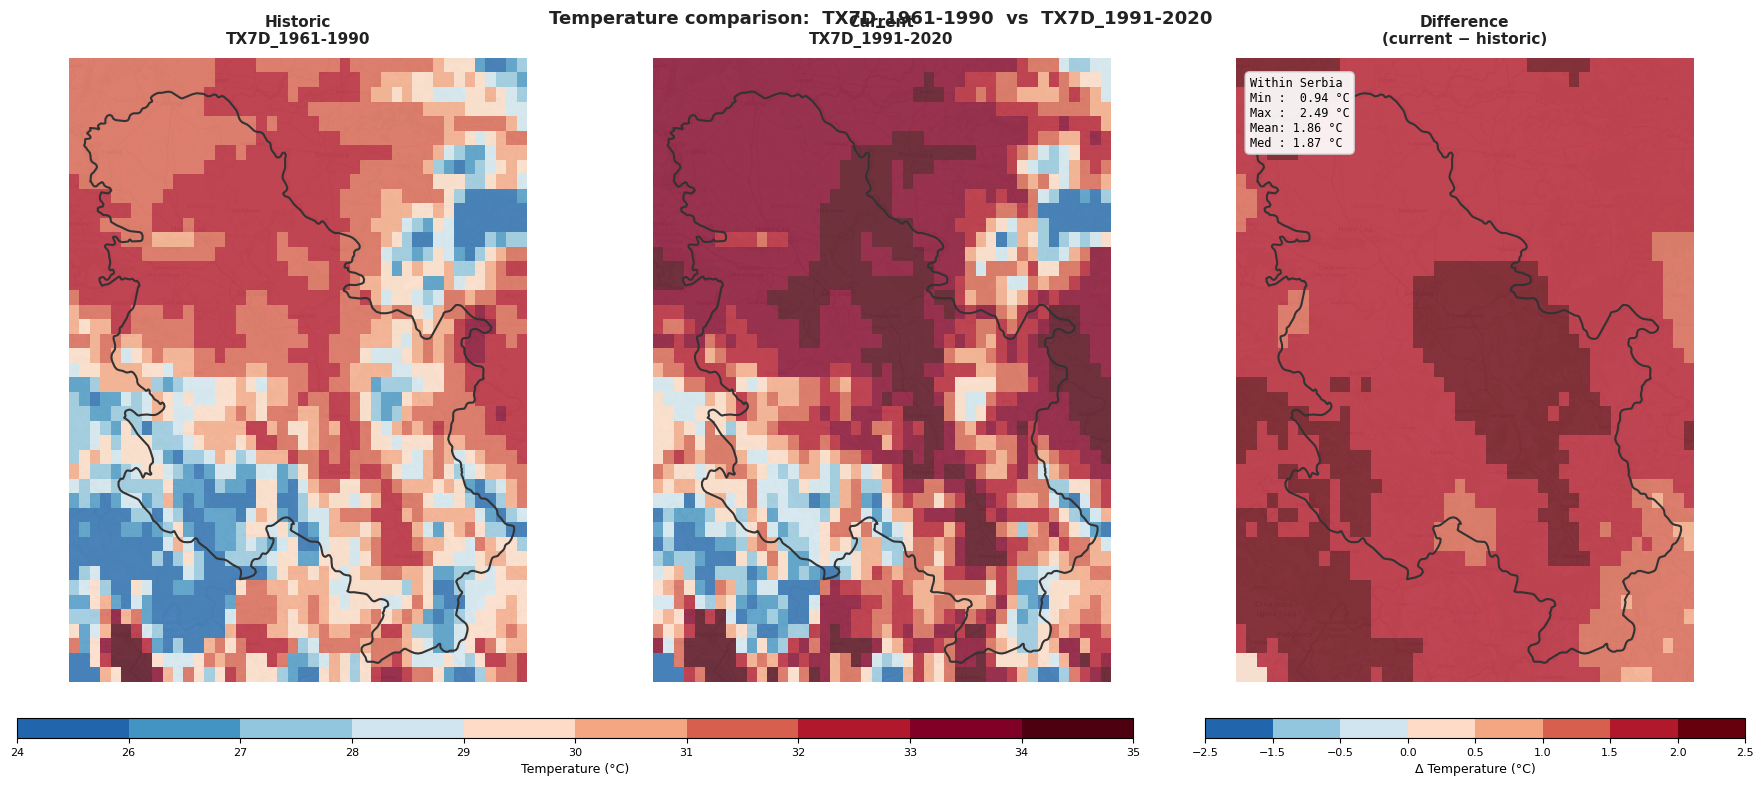

In [42]:
def plot_difference(historic_path, current_path, serbia_3857, output_folder):
    hist_stem = os.path.splitext(os.path.basename(historic_path))[0]
    curr_stem = os.path.splitext(os.path.basename(current_path))[0]

    hist_data, hist_bounds, hist_crs = read_tif(historic_path)
    curr_data, curr_bounds, curr_crs = read_tif(current_path)

    # Extent mismatch warning
    if any(abs(getattr(hist_bounds, k) - getattr(curr_bounds, k)) > 0.5
           for k in ("left", "right", "bottom", "top")):
        print("⚠ Warning: spatial extents differ — difference values may be unreliable.")

    # Resample if grids differ
    if hist_data.shape != curr_data.shape:
        print(f"  Resampling historic {hist_data.shape} → current {curr_data.shape} …")
        hist_data = resample_to_match(hist_data, curr_data)

    diff_data = curr_data - hist_data

    # ── Statistics: Serbia pixels only ───────────────────────────────────────
    diff_serbia = mask_to_serbia(diff_data, curr_bounds, curr_crs, serbia_3857)
    valid       = diff_serbia[~np.isnan(diff_serbia)]

    if len(valid) == 0:
        print("⚠ No valid pixels found inside Serbia — check raster extent.")
    else:
        print("─" * 45)
        print(f"  Difference statistics (within Serbia)")
        print(f"  {'Pixels used':<20}: {len(valid):,}")
        print(f"  {'Min  Δ':<20}: {valid.min():.4f} °C")
        print(f"  {'Max  Δ':<20}: {valid.max():.4f} °C")
        print(f"  {'Mean Δ':<20}: {valid.mean():.4f} °C")
        print(f"  {'Median Δ':<20}: {np.median(valid):.4f} °C")
        print(f"  {'Std dev Δ':<20}: {valid.std():.4f} °C")
        print("─" * 45)

    # ── Colormaps & norms ─────────────────────────────────────────────────────
    cmap_abs  = ListedColormap(ABS_COLORS)
    norm_abs  = BoundaryNorm(ABS_BINS, cmap_abs.N)
    cmap_diff = ListedColormap(DIFF_COLORS)
    norm_diff = BoundaryNorm(DIFF_BINS, cmap_diff.N)

    # Web-Mercator extent (same for all three panels)
    l, b, r, t = _reproject_bounds_to_3857(curr_bounds, curr_crs)
    ext = [l, r, b, t]

    # ── Figure layout ─────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 8), facecolor="white")
    fig.subplots_adjust(
        left=0.02, right=0.98,
        top=0.91,  bottom=0.13,
        wspace=0.04,
    )
    fig.suptitle(
        f"Temperature comparison:  {hist_stem}  vs  {curr_stem}",
        fontsize=13, fontweight="bold", y=0.97, color="#222222",
    )

    datasets = [
        (hist_data, norm_abs,  cmap_abs,  f"Historic\n{hist_stem}"),
        (curr_data, norm_abs,  cmap_abs,  f"Current\n{curr_stem}"),
        (diff_data, norm_diff, cmap_diff, "Difference\n(current − historic)"),
    ]

    for ax, (data, norm, cmap, title) in zip(axes, datasets):
        ax.imshow(
            data,
            extent=ext,
            origin="upper",
            cmap=cmap,
            norm=norm,
            interpolation="nearest",
            alpha=0.80,
            zorder=3,
        )
        _apply_panel_style(ax, title, serbia_3857)

    # ── Stats annotation on the difference panel ──────────────────────────────
    if len(valid) > 0:
        stats_text = (
            f"Within Serbia\n"
            f"Min :  {valid.min():.2f} °C\n"
            f"Max :  {valid.max():.2f} °C\n"
            f"Mean: {valid.mean():.2f} °C\n"
            f"Med : {np.median(valid):.2f} °C"
        )
        axes[2].text(
            0.03, 0.97, stats_text,
            transform=axes[2].transAxes,
            fontsize=8.5, verticalalignment="top",
            fontfamily="monospace",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="#cccccc", alpha=0.92),
            zorder=10,
        )

    # ── Shared horizontal colorbar — absolute panels (Historic + Current) ─────
    sm_abs = plt.cm.ScalarMappable(cmap=cmap_abs, norm=norm_abs)
    sm_abs.set_array([])
    # Span under the first two panels
    cax_abs = fig.add_axes([0.02, 0.06, 0.62, 0.025])
    cbar_abs = fig.colorbar(sm_abs, cax=cax_abs, orientation="horizontal")
    cbar_abs.set_label("Temperature (°C)", fontsize=9)
    cbar_abs.set_ticks(ABS_BINS)
    cbar_abs.ax.tick_params(labelsize=8)

    # ── Horizontal colorbar — difference panel ────────────────────────────────
    sm_diff = plt.cm.ScalarMappable(cmap=cmap_diff, norm=norm_diff)
    sm_diff.set_array([])
    # Span under the third panel
    cax_diff = fig.add_axes([0.68, 0.06, 0.30, 0.025])
    cbar_diff = fig.colorbar(sm_diff, cax=cax_diff, orientation="horizontal")
    cbar_diff.set_label("Δ Temperature (°C)", fontsize=9)
    cbar_diff.set_ticks(DIFF_BINS)
    cbar_diff.ax.tick_params(labelsize=8)

    _save_or_show(fig, output_folder, f"diff_{hist_stem}_vs_{curr_stem}")


# ── Run ───────────────────────────────────────────────────────────────────────
if HISTORIC_TIF and CURRENT_TIF:
    for p in (HISTORIC_TIF, CURRENT_TIF):
        if not os.path.isfile(p):
            raise FileNotFoundError(f"File not found: {p}")
    print(f"Difference mode\n  Historic : {HISTORIC_TIF}\n  Current  : {CURRENT_TIF}\n")
    plot_difference(HISTORIC_TIF, CURRENT_TIF, serbia_3857, OUTPUT_FOLDER)
else:
    print("Difference mode is off.\n"
          "Set HISTORIC_TIF and CURRENT_TIF in the Config cell to enable it.")

In [43]:
#config for pavement plotting
ABS_BINS_PAV   = [50, 53, 56, 59, 62, 64]
ABS_COLORS_PAV = [
    "#ffffb2",  # 50 – 53
    "#fecc5c",  # 53 – 56
    "#fd8d3c",  # 56 – 59
    "#f03b20",  # 59 – 62
    "#bd0026",  # 62 – 64
]

In [44]:
#ffffb2
#fecc5c
#fd8d3c
#f03b20
#bd0026

In [45]:
def plot_single(tif_path_or_data, title, output_folder, bounds=None, crs=None):
    if isinstance(tif_path_or_data, str):
        data, bounds, crs = read_tif(tif_path_or_data)
        stem = os.path.splitext(os.path.basename(tif_path_or_data))[0]
    else:
        data = tif_path_or_data
        stem = title.lower().replace(" ", "_")

    l, b, r, t = _reproject_bounds_to_3857(bounds, crs)

    cmap = ListedColormap(ABS_COLORS_PAV)
    norm = BoundaryNorm(ABS_BINS_PAV, cmap.N)

    # ── Bin statistics (Serbia only) ──────────────────────────────────────────
    data_serbia = mask_to_serbia(data, bounds, crs, serbia_3857)
    valid = data_serbia[~np.isnan(data_serbia)]

    print(f"Bin distribution for: {title}")
    print(f"  {'Bin':<15} {'Cells':>8}  {'% of total':>10}")
    print("  " + "─" * 37)

    # Below lowest bin
    n = (valid < ABS_BINS_PAV[0]).sum()
    print(f"  {'< ' + str(ABS_BINS_PAV[0]):<15} {n:>8,}  {n/len(valid)*100:>9.1f}%")

    # Each bin
    for lo, hi in zip(ABS_BINS_PAV[:-1], ABS_BINS_PAV[1:]):
        n = ((valid >= lo) & (valid < hi)).sum()
        print(f"  {f'{lo} – {hi}':<15} {n:>8,}  {n/len(valid)*100:>9.1f}%")

    # Above highest bin
    n = (valid >= ABS_BINS_PAV[-1]).sum()
    print(f"  {'> ' + str(ABS_BINS_PAV[-1]):<15} {n:>8,}  {n/len(valid)*100:>9.1f}%")

    print(f"  {'─' * 37}")
    print(f"  {'Total':<15} {len(valid):>8,}  {'100.0%':>10}")
    print()

    fig, ax = plt.subplots(figsize=(8, 9), facecolor="white")
    fig.subplots_adjust(left=0.02, right=0.98, top=0.94, bottom=0.10)

    ax.imshow(
        data,
        extent=[l, r, b, t],
        origin="upper",
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
        alpha=0.80,
        zorder=3,
    )
    _apply_panel_style(ax, title, serbia_3857)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = fig.add_axes([0.15, 0.05, 0.70, 0.025])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal", extend="both")
    cbar.set_label("Pavement Temperature (°C)", fontsize=9)
    cbar.set_ticks(ABS_BINS_PAV)
    cbar.set_ticks(ABS_BINS_PAV)
    cbar.ax.set_xticklabels(["<50", "53", "56", "59", "62", ">64"], fontsize=8)

    _save_or_show(fig, output_folder, stem)


In [46]:
data, bounds, crs = read_tif(CURRENT_PAV_TEMP_TIF)

# Mask to Serbia only
data_serbia = mask_to_serbia(data, bounds, crs, serbia_3857)
valid = data_serbia[~np.isnan(data_serbia)]

print(f"Min  : {valid.min():.2f} °C")
print(f"Max  : {valid.max():.2f} °C")
print(f"\nQuintile breaks (5 equal portions):")
for p, v in zip([0, 20, 40, 60, 80, 100], np.percentile(valid, [0, 20, 40, 60, 80, 100])):
    print(f"  {p:>3}th percentile: {v:.2f} °C")

Min  : 46.97 °C
Max  : 56.95 °C

Quintile breaks (5 equal portions):
    0th percentile: 46.97 °C
   20th percentile: 52.41 °C
   40th percentile: 54.07 °C
   60th percentile: 54.72 °C
   80th percentile: 55.05 °C
  100th percentile: 56.95 °C


Bin distribution for: Pavement Temperature
  Bin                Cells  % of total
  ─────────────────────────────────────
  < 50                  56        6.4%
  50 – 53              171       19.4%
  53 – 56              630       71.6%
  56 – 59               23        2.6%
  59 – 62                0        0.0%
  62 – 64                0        0.0%
  > 64                   0        0.0%
  ─────────────────────────────────────
  Total                880      100.0%

  Saved → c:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\figures\temperature\pavement_temperature.png


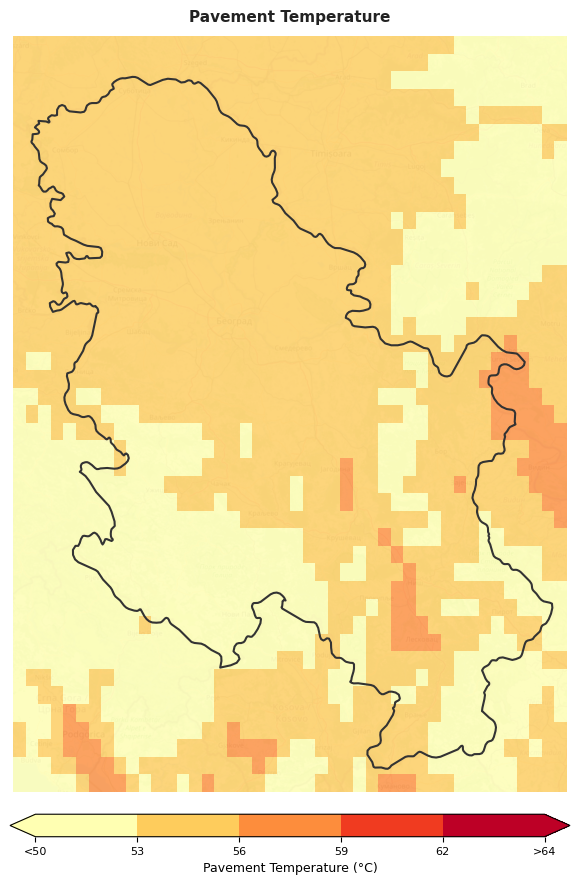

In [47]:
#plot max 7 day pavement temperature (average 2021 to 2025)
plot_single(data, "Pavement Temperature", OUTPUT_FOLDER, bounds=bounds, crs=crs)

Bin distribution for: Pavement Temperature (+ 2°C)
  Bin                Cells  % of total
  ─────────────────────────────────────
  < 50                   4        0.5%
  50 – 53               89       10.1%
  53 – 56              247       28.1%
  56 – 59              540       61.4%
  59 – 62                0        0.0%
  62 – 64                0        0.0%
  > 64                   0        0.0%
  ─────────────────────────────────────
  Total                880      100.0%

  Saved → c:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\figures\temperature\pavement_temperature_(+_2°c).png


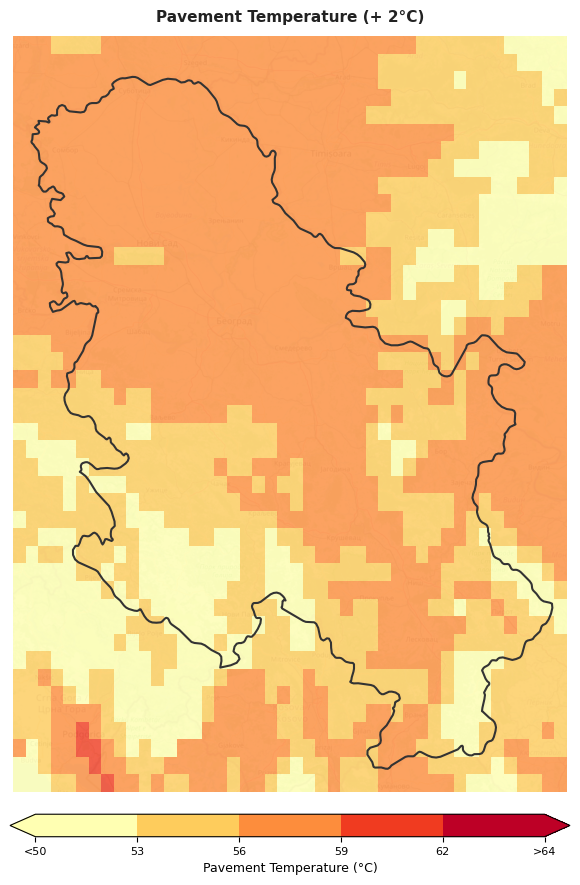

In [48]:
# Adjust for future climate change
data_future = data + 2
plot_single(data_future, "Pavement Temperature (+ 2°C)", OUTPUT_FOLDER, bounds=bounds, crs=crs)

In [49]:
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.mask import mask as rio_mask
import rasterio
import numpy as np

# ── Reproject climate bounds into SMOD CRS (Mollweide) ───────────────────────
climate_bounds_mollweide = transform_bounds(
    "EPSG:4326",    # from
    "ESRI:54009",   # to
    bounds.left, bounds.bottom, bounds.right, bounds.top
)
print("Climate bounds in Mollweide:", climate_bounds_mollweide)

# ── Reproject SMOD to EPSG:4326 clipped to climate extent ────────────────────
# First figure out the output shape and transform
from rasterio.warp import calculate_default_transform

with rasterio.open(DEGREE_OF_URBANIZATION_TIF) as smod_src:
    # Calculate transform for reprojected SMOD in EPSG:4326
    # matching the climate raster extent
    dst_transform, dst_width, dst_height = calculate_default_transform(
        smod_src.crs,
        "EPSG:4326",
        smod_src.width,
        smod_src.height,
        *smod_src.bounds,
        dst_width  = 1000,   # keep manageable resolution
        dst_height = 1000,
    )

    smod_reprojected = np.empty((dst_height, dst_width), dtype=np.float32)

    reproject(
        source        = rasterio.band(smod_src, 1),
        destination   = smod_reprojected,
        src_transform = smod_src.transform,
        src_crs       = smod_src.crs,
        dst_transform = dst_transform,
        dst_crs       = "EPSG:4326",
        resampling    = Resampling.nearest,   # nearest for class data — never interpolate classes
        src_nodata    = smod_src.nodata,
        dst_nodata    = np.nan,
    )

smod_reprojected = smod_reprojected.astype(float)

# ── Clip SMOD to the climate raster extent ───────────────────────────────────
# Get pixel coordinates of the climate bounds within the reprojected SMOD
from rasterio.transform import rowcol

row_min, col_min = rowcol(dst_transform, bounds.left,  bounds.top,    op=int)
row_max, col_max = rowcol(dst_transform, bounds.right, bounds.bottom, op=int)

# Clamp to valid array bounds
row_min = max(0, row_min)
col_min = max(0, col_min)
row_max = min(dst_height, row_max)
col_max = min(dst_width,  col_max)

smod_clipped = smod_reprojected[row_min:row_max, col_min:col_max]
print("SMOD clipped shape:", smod_clipped.shape)
print("Unique SMOD classes:", np.unique(smod_clipped[~np.isnan(smod_clipped)]))

# ── Reproject climate onto the clipped SMOD grid ─────────────────────────────
# Compute the transform for the clipped SMOD window
from rasterio.transform import from_bounds as transform_from_bounds

smod_clip_transform = transform_from_bounds(
    bounds.left, bounds.bottom, bounds.right, bounds.top,
    smod_clipped.shape[1], smod_clipped.shape[0]
)

data_reprojected = np.empty(smod_clipped.shape, dtype=np.float32)


with rasterio.open(CURRENT_PAV_TEMP_TIF) as climate_src:
    reproject(
        source        = rasterio.band(climate_src, 1),
        destination   = data_reprojected,
        dst_crs       = "EPSG:4326",
        dst_transform = smod_clip_transform,
        resampling    = Resampling.nearest,   # ← was bilinear
    )

data_reprojected = data_reprojected.astype(float)
data_reprojected = np.where(data_reprojected <= 0, np.nan, data_reprojected)

# ── Apply offsets ─────────────────────────────────────────────────────────────
data_future_fine = data_reprojected + 2

UHI_OFFSETS = {
    30: 5.0,   # Urban Centre
    23: 5.0,   # Dense Urban Cluster
    22: 5.0,   # Semi-dense Cluster
}

data_uhi = data_future_fine.copy()
for smod_class, offset in UHI_OFFSETS.items():
    mask = smod_clipped == smod_class
    data_uhi[mask] = data_uhi[mask] + offset
    print(f"  Class {smod_class}: {mask.sum():>8,} cells  (+{offset}°C)")

# bounds and crs to pass into plot_single
uhi_bounds = bounds   # now in EPSG:4326 matching climate raster
uhi_crs    = "EPSG:4326"

print(f"\nOutput shape : {data_uhi.shape}")
print(f"Min          : {np.nanmin(data_uhi):.2f} °C")
print(f"Max          : {np.nanmax(data_uhi):.2f} °C")

Climate bounds in Mollweide: (1486807.6856812085, 5022734.234321175, 1922992.22326269, 5491412.46115576)
SMOD clipped shape: (462, 300)
Unique SMOD classes: [10. 11. 12. 13. 21. 22. 23. 30.]
  Class 30:      724 cells  (+5.0°C)
  Class 23:      515 cells  (+5.0°C)
  Class 22:      200 cells  (+5.0°C)

Output shape : (462, 300)
Min          : 43.51 °C
Max          : 64.81 °C


Bin distribution for: Pavement Temperature with urban heat islands under climate change
  Bin                Cells  % of total
  ─────────────────────────────────────
  < 50                 261        0.4%
  50 – 53            6,429       10.0%
  53 – 56           17,945       28.0%
  56 – 59           38,570       60.2%
  59 – 62              476        0.7%
  62 – 64              365        0.6%
  > 64                   0        0.0%
  ─────────────────────────────────────
  Total             64,046      100.0%

  Saved → c:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\figures\temperature\pavement_temperature_with_urban_heat_islands_under_climate_change.png


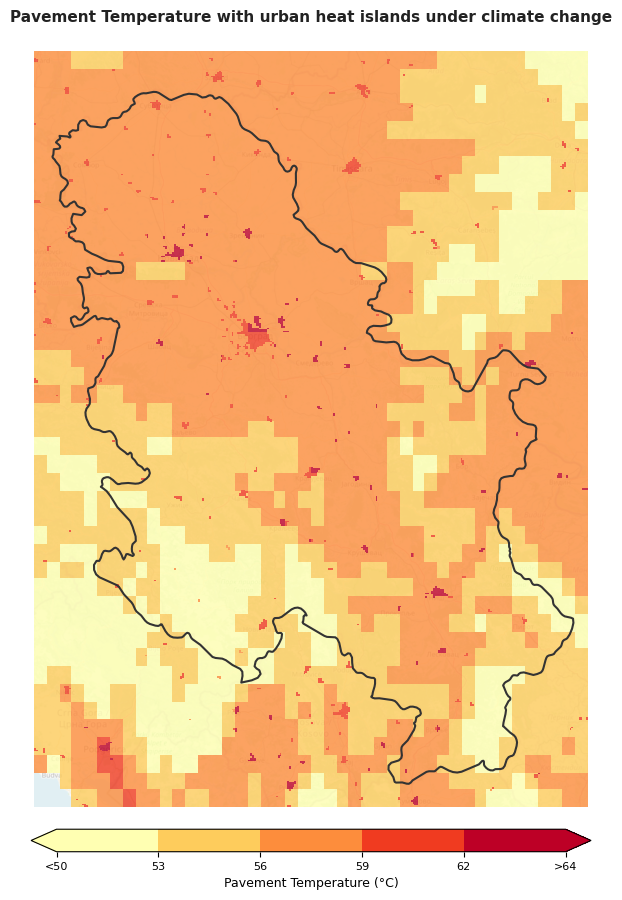

In [50]:
plot_single(data_uhi, "Pavement Temperature with urban heat islands under climate change", OUTPUT_FOLDER, bounds=bounds, crs=crs)

Roads with temperature assigned : 5,490
Roads outside raster extent     : 0
Temperature range on roads      : 50.42 – 63.91 °C
Saved → PERS_directed_final_with_temp.parquet
  Saved → c:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\figures\temperature\road_network_max_temp.png


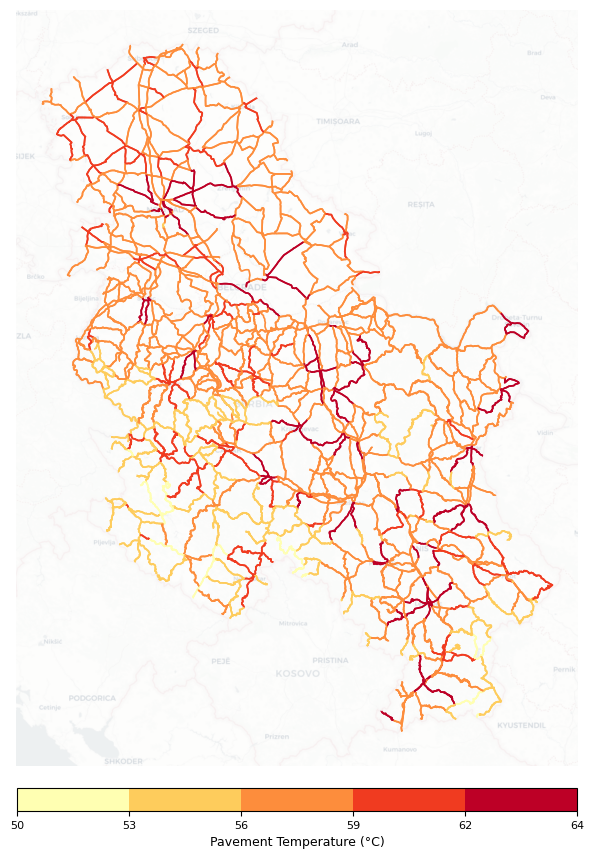

Road segment distribution:
  Bin                Roads  % of total
  ─────────────────────────────────────
  50 – 53               64        1.2%
  53 – 56              544        9.9%
  56 – 59            3,950       71.9%
  59 – 62              520        9.5%
  62 – 64              412        7.5%
  ─────────────────────────────────────
  Total              5,490      100.0%


In [51]:
from rasterstats import zonal_stats
import pandas as pd

# ── Load roads ────────────────────────────────────────────────────────────────
roads = gpd.read_parquet(intermediate_results_path / "PERS_directed_final.parquet")

# Ensure roads are in the same CRS as the temperature data
roads = roads.to_crs(uhi_crs)

# ── Build a rasterio-compatible dataset in memory for rasterstats ─────────────
from rasterio.transform import from_bounds as transform_from_bounds
from rasterio.io import MemoryFile
import rasterio

rows, cols   = data_uhi.shape
raster_transform = transform_from_bounds(
    bounds.left, bounds.bottom, bounds.right, bounds.top, cols, rows
)

with MemoryFile() as memfile:
    with memfile.open(
        driver    = "GTiff",
        height    = rows,
        width     = cols,
        count     = 1,
        dtype     = data_uhi.dtype,
        crs       = uhi_crs,
        transform = raster_transform,
    ) as dataset:
        dataset.write(data_uhi, 1)

    # ── Assign max temperature to each road segment ───────────────────────────
    stats = zonal_stats(
        roads,
        memfile.name,
        stats    = ["max"],
        nodata   = np.nan,
        all_touched = True,   # include cells the line merely touches
    )

roads["max_temp"] = [s["max"] for s in stats]

# Flag roads with no temperature data (outside raster extent)
n_missing = roads["max_temp"].isna().sum()
print(f"Roads with temperature assigned : {(~roads['max_temp'].isna()).sum():,}")
print(f"Roads outside raster extent     : {n_missing:,}")
print(f"Temperature range on roads      : {roads['max_temp'].min():.2f} – {roads['max_temp'].max():.2f} °C")

# ── Save to parquet ───────────────────────────────────────────────────────────
roads.to_parquet(intermediate_results_path / "PERS_directed_final_with_temp.parquet")
print("Saved → PERS_directed_final_with_temp.parquet")

# ── Plot ──────────────────────────────────────────────────────────────────────
roads_plot = roads.to_crs(epsg=3857)
serbia_3857_plot = serbia_3857.to_crs(epsg=3857)

cmap = ListedColormap(ABS_COLORS_PAV)
norm = BoundaryNorm(ABS_BINS_PAV, cmap.N)

fig, ax = plt.subplots(figsize=(8, 9), facecolor="white")
fig.subplots_adjust(left=0.02, right=0.98, top=0.94, bottom=0.10)

# Roads without temperature (outside extent) in grey
roads_no_temp = roads_plot[roads_plot["max_temp"].isna()]
if len(roads_no_temp) > 0:
    roads_no_temp.plot(ax=ax, color="grey", linewidth=0.4, alpha=0.5, zorder=3)

# Roads coloured by max temperature
roads_with_temp = roads_plot[~roads_plot["max_temp"].isna()]
roads_with_temp.plot(
    ax       = ax,
    column   = "max_temp",
    cmap     = cmap,
    norm     = norm,
    linewidth = 1.2,
    zorder   = 4,
)

# Serbia outline and basemap
#serbia_3857_plot.plot(ax=ax, facecolor="none", edgecolor="#333333", linewidth=1.5, zorder=5)
cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron, alpha=0.4, attribution=False)

ax.set_aspect("equal")
ax.margins(0)
ax.axis("off")
#ax.set_title("Road Network — Max Pavement Temperature", fontsize=11, fontweight="bold", pad=10)

# Horizontal colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cax = fig.add_axes([0.15, 0.05, 0.70, 0.025])
cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
cbar.set_label("Pavement Temperature (°C)", fontsize=9)
cbar.set_ticks(ABS_BINS_PAV)
cbar.ax.set_xticklabels(["50", "53", "56", "59", "62", "64"], fontsize=8)

_save_or_show(fig, OUTPUT_FOLDER, "road_network_max_temp")

valid_temps = roads["max_temp"].dropna()

print(f"Road segment distribution:")
print(f"  {'Bin':<15} {'Roads':>8}  {'% of total':>10}")
print("  " + "─" * 37)

for lo, hi in zip(ABS_BINS_PAV[:-1], ABS_BINS_PAV[1:]):
    n = ((valid_temps >= lo) & (valid_temps < hi)).sum()
    print(f"  {f'{lo} – {hi}':<15} {n:>8,}  {n/len(valid_temps)*100:>9.1f}%")

print(f"  {'─' * 37}")
print(f"  {'Total':<15} {len(valid_temps):>8,}  {'100.0%':>10}")

In [52]:
def assign_and_plot_road_temperatures(raster_data, raster_bounds, raster_crs, 
                                       input_parquet, output_parquet, output_folder, title=None):
    """
    Assigns max temperature from raster to each road segment,
    saves the result to parquet, prints bin distribution and plots the road network.
    """
    from rasterstats import zonal_stats
    from rasterio.transform import from_bounds as transform_from_bounds
    from rasterio.io import MemoryFile

    # ── Load roads ────────────────────────────────────────────────────────────
    roads = gpd.read_parquet(input_parquet)
    roads = roads.to_crs(raster_crs)

    # ── Write raster to memory for rasterstats ────────────────────────────────
    rows, cols        = raster_data.shape
    raster_transform  = transform_from_bounds(
        raster_bounds.left, raster_bounds.bottom,
        raster_bounds.right, raster_bounds.top,
        cols, rows
    )

    with MemoryFile() as memfile:
        with memfile.open(
            driver    = "GTiff",
            height    = rows,
            width     = cols,
            count     = 1,
            dtype     = raster_data.dtype,
            crs       = raster_crs,
            transform = raster_transform,
        ) as dataset:
            dataset.write(raster_data, 1)

        stats = zonal_stats(
            roads,
            memfile.name,
            stats       = ["max"],
            nodata      = np.nan,
            all_touched = True,
        )

    roads["max_temp"] = [s["max"] for s in stats]

    # ── Print summary ─────────────────────────────────────────────────────────
    n_missing = roads["max_temp"].isna().sum()
    print(f"Roads with temperature assigned : {(~roads['max_temp'].isna()).sum():,}")
    print(f"Roads outside raster extent     : {n_missing:,}")
    print(f"Temperature range on roads      : {roads['max_temp'].min():.2f} – {roads['max_temp'].max():.2f} °C")

    # ── Bin distribution ──────────────────────────────────────────────────────
    valid_temps = roads["max_temp"].dropna()
    print(f"\nRoad segment distribution:")
    print(f"  {'Bin':<15} {'Roads':>8}  {'% of total':>10}")
    print("  " + "─" * 37)
    for lo, hi in zip(ABS_BINS_PAV[:-1], ABS_BINS_PAV[1:]):
        n = ((valid_temps >= lo) & (valid_temps < hi)).sum()
        print(f"  {f'{lo} – {hi}':<15} {n:>8,}  {n/len(valid_temps)*100:>9.1f}%")
    print(f"  {'─' * 37}")
    print(f"  {'Total':<15} {len(valid_temps):>8,}  {'100.0%':>10}")

    # ── Save to parquet ───────────────────────────────────────────────────────
    roads.to_parquet(output_parquet)
    print(f"\nSaved → {output_parquet}")

    # ── Plot ──────────────────────────────────────────────────────────────────
    roads_plot = roads.to_crs(epsg=3857)

    cmap = ListedColormap(ABS_COLORS_PAV)
    norm = BoundaryNorm(ABS_BINS_PAV, cmap.N)

    fig, ax = plt.subplots(figsize=(8, 9), facecolor="white")
    fig.subplots_adjust(left=0.02, right=0.98, top=0.94, bottom=0.10)

    roads_no_temp = roads_plot[roads_plot["max_temp"].isna()]
    if len(roads_no_temp) > 0:
        roads_no_temp.plot(ax=ax, color="grey", linewidth=0.4, alpha=0.5, zorder=3)

    roads_with_temp = roads_plot[~roads_plot["max_temp"].isna()]
    roads_with_temp.plot(
        ax        = ax,
        column    = "max_temp",
        cmap      = cmap,
        norm      = norm,
        linewidth = 1.2,
        zorder    = 4,
    )

    cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron, alpha=0.4, attribution=False)
    ax.set_aspect("equal")
    ax.margins(0)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=11, fontweight="bold", pad=10, color="#222222")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = fig.add_axes([0.15, 0.05, 0.70, 0.025])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label("Pavement Temperature (°C)", fontsize=9)
    cbar.set_ticks(ABS_BINS_PAV)
    cbar.ax.set_xticklabels(["50", "53", "56", "59", "62", "64"], fontsize=8)

    stem = output_parquet.stem
    _save_or_show(fig, output_folder, stem)

Current max pavement temperatures
Roads with temperature assigned : 5,490
Roads outside raster extent     : 0
Temperature range on roads      : 48.42 – 56.95 °C

Road segment distribution:
  Bin                Roads  % of total
  ─────────────────────────────────────
  50 – 53              324        5.9%
  53 – 56            4,698       85.6%
  56 – 59              426        7.8%
  59 – 62                0        0.0%
  62 – 64                0        0.0%
  ─────────────────────────────────────
  Total              5,490      100.0%

Saved → c:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\intermediate_results\PERS_directed_final_with_temp.parquet
  Saved → c:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\figures\temperature\PERS_directed_final_with_temp.png


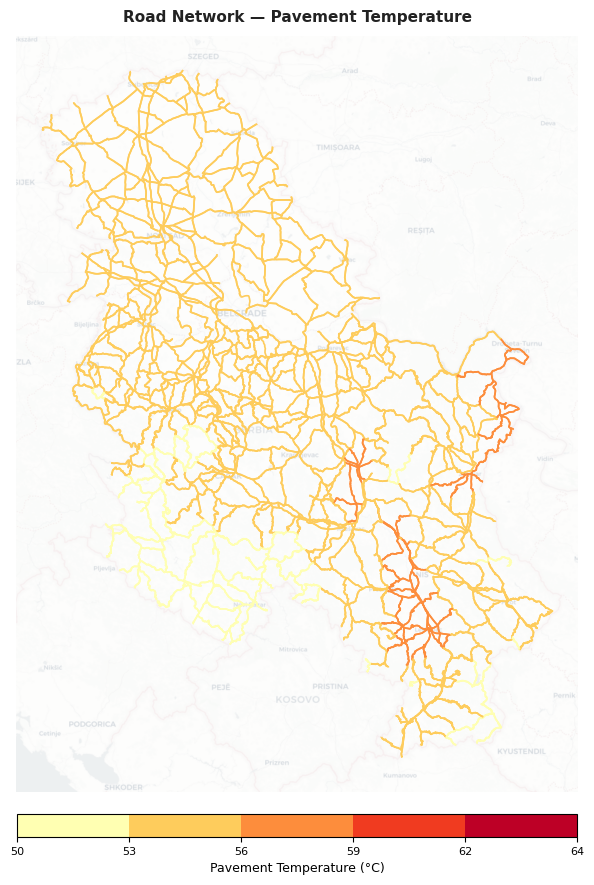

In [53]:
# Original pavement temperatures
print("Current max pavement temperatures")
assign_and_plot_road_temperatures(
    raster_data   = data,
    raster_bounds = bounds,
    raster_crs    = crs,
    input_parquet  = intermediate_results_path / "PERS_directed_final.parquet",
    output_parquet = intermediate_results_path / "PERS_directed_final_with_temp.parquet",
    output_folder  = OUTPUT_FOLDER,
    title          = "Road Network — Pavement Temperature",
)

Future max pavement temperatures considering climate change and urban heat islands
Roads with temperature assigned : 5,490
Roads outside raster extent     : 0
Temperature range on roads      : 50.42 – 63.91 °C

Road segment distribution:
  Bin                Roads  % of total
  ─────────────────────────────────────
  50 – 53               64        1.2%
  53 – 56              544        9.9%
  56 – 59            3,950       71.9%
  59 – 62              520        9.5%
  62 – 64              412        7.5%
  ─────────────────────────────────────
  Total              5,490      100.0%

Saved → c:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\intermediate_results\PERS_directed_final_with_temp_uhi.parquet
  Saved → c:\Users\yma794\Documents\Serbia\analysis rerun 23_3\Criticality-Analysis-Roads-Serbia\figures\temperature\PERS_directed_final_with_temp_uhi.png


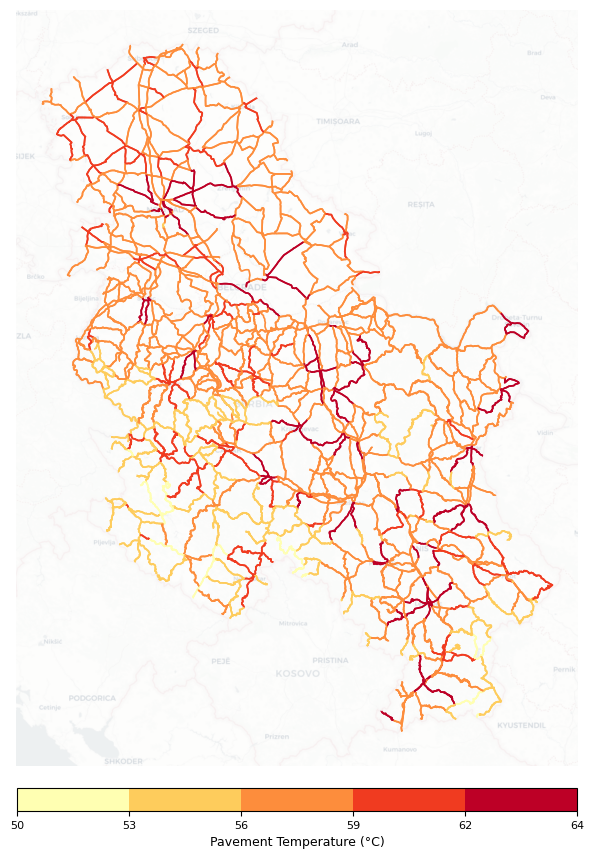

In [54]:
# Future temperatures with UHI
print("Future max pavement temperatures considering climate change and urban heat islands")
assign_and_plot_road_temperatures(
    raster_data   = data_uhi,
    raster_bounds = bounds,
    raster_crs    = uhi_crs,
    input_parquet  = intermediate_results_path / "PERS_directed_final.parquet",
    output_parquet = intermediate_results_path / "PERS_directed_final_with_temp_uhi.parquet",
    output_folder  = OUTPUT_FOLDER,
)